# 01. DUT Anti-UAV 데이터 분석
1. train / val / test 파일 수
2. XML 라벨 구조
3. 실제 이미지와 bbox 확인
4. bbox 크기 통계
5. 작은 객체 비율
6. 640 입력 시 예상 bbox 크기
7. 밝기 / 대비


## 1. 라이브러리와 데이터 경로

In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET

import cv2
import pandas as pd
import matplotlib.pyplot as plt

# notebooks 폴더에서 실행하므로 ../data/raw 사용
DATA_ROOT = Path('../data/raw')

print(DATA_ROOT.resolve())


/home/sswwd/projects/small-drone-detection/data/raw


## 2. train / val / test 파일 수 확인

In [2]:
for split in ['train', 'val', 'test']:
    path = DATA_ROOT / split

    images = list(path.rglob('*.jpg'))
    xmls = list(path.rglob('*.xml'))

    print(f'{split:5} | images: {len(images):5} | xml: {len(xmls):5}')


train | images:  5200 | xml:  5200
val   | images:  2600 | xml:  2600
test  | images:  2200 | xml:  2200


## 3. XML 라벨 하나 확인

In [7]:
train_xmls = sorted((DATA_ROOT / 'train').rglob('*.xml'))

sample_xml = train_xmls[0]
print(sample_xml)
print()
print(sample_xml.read_text(encoding='utf-8'))


../data/raw/train/train/xml/00001.xml

<annotation>
	<folder>train</folder>
	<filename>00001.jpg</filename>
	<path>./train/00001.jpg</path>
	<source>
		<database>DUT Anti-UAV Detection</database>
	</source>
	<size>
		<width>550</width>
		<height>412</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>UAV</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>228</xmin>
			<ymin>155</ymin>
			<xmax>353</xmax>
			<ymax>245</ymax>
		</bndbox>
	</object>
</annotation>



## 4. XML에서 bbox 읽기

`xmin, ymin, xmax, ymax`가 Ground Truth bbox입니다.

In [8]:
def read_xml(xml_path):
    root = ET.parse(xml_path).getroot()

    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)

    boxes = []

    for obj in root.findall('object'):
        box = obj.find('bndbox')

        xmin = int(float(box.find('xmin').text))
        ymin = int(float(box.find('ymin').text))
        xmax = int(float(box.find('xmax').text))
        ymax = int(float(box.find('ymax').text))

        boxes.append([xmin, ymin, xmax, ymax])

    return width, height, boxes


width, height, boxes = read_xml(sample_xml)
print('이미지 크기:', width, 'x', height)
print('bbox:', boxes)


이미지 크기: 550 x 412
bbox: [[228, 155, 353, 245]]


## 5. 실제 이미지에 Ground Truth bbox 그려보기

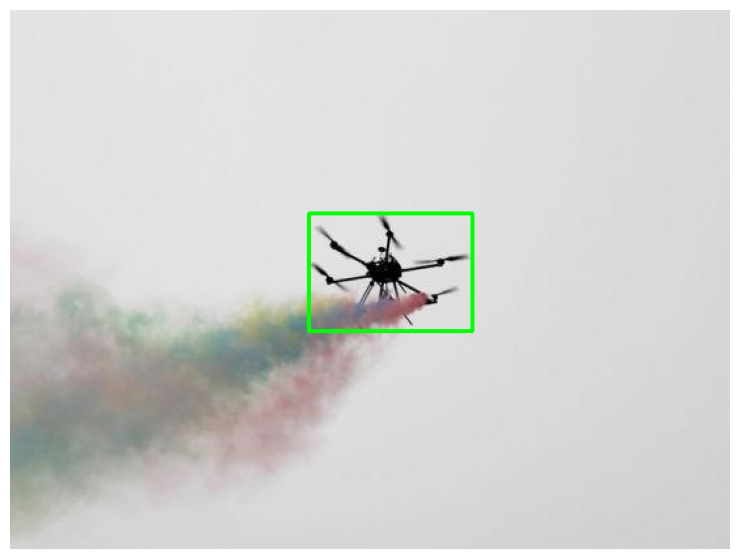

In [9]:
# XML과 같은 이름의 jpg 찾기
image_name = sample_xml.stem + '.jpg'
sample_image = list((DATA_ROOT / 'train').rglob(image_name))[0]

image = cv2.imread(str(sample_image))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

_, _, boxes = read_xml(sample_xml)

for xmin, ymin, xmax, ymax in boxes:
    cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis('off')
plt.show()


## 6. 전체 bbox 정보를 표로 만들기

나중에 작은 객체 비율과 split별 차이를 확인하기 위한 표

In [ ]:
rows = []

for split in ['train', 'val', 'test']:
    xmls = sorted((DATA_ROOT / split).rglob('*.xml'))

    for xml_path in xmls:
        width, height, boxes = read_xml(xml_path)

        for xmin, ymin, xmax, ymax in boxes:
            bbox_w = xmax - xmin
            bbox_h = ymax - ymin
            bbox_ratio = (bbox_w * bbox_h) / (width * height)

            rows.append({
                'split': split,
                'image_width': width,
                'image_height': height,
                'bbox_width': bbox_w,
                'bbox_height': bbox_h,
                'bbox_ratio': bbox_ratio #전체 이미지 면적에서 bbox가 차지하는 비율
            })

df = pd.DataFrame(rows)

# SAVE_DIR = Path("../results/data_analysis")
# SAVE_DIR.mkdir(parents=True, exist_ok=True)

# df.to_csv(SAVE_DIR / "bbox_stats.csv", index=False)

df.head()


,split,image_width,image_height,bbox_width,bbox_height,bbox_ratio
0,train,550,412,125,90,0.049647
1,train,1000,667,493,384,0.283826
2,train,511,317,317,204,0.399217
3,train,479,261,276,166,0.366472
4,train,579,388,340,197,0.298150


## 7. bbox 크기와 작은 객체 비율 확인

In [21]:
# split 순서
split_order = ['train', 'val', 'test']

# 필요한 통계 계산
stats = []

for split in split_order:
    temp = df[df['split'] == split]

    stats.append({
        'split': split,
        '객체 수': len(temp),
        'bbox width 중앙값': temp['bbox_width'].median(),
        'bbox height 중앙값': temp['bbox_height'].median(),
        'bbox 면적 중앙값(%)': temp['bbox_ratio'].median() * 100,
        '1% 미만 객체(%)': (temp['bbox_ratio'] < 0.01).mean() * 100,
        '5% 미만 객체(%)': (temp['bbox_ratio'] < 0.05).mean() * 100
    })

stats_df = pd.DataFrame(stats)

stats_df

,split,객체 수,bbox width 중앙값,bbox height 중앙값,bbox 면적 중앙값(%),1% 미만 객체(%),5% 미만 객체(%)
0,train,5243,43.0,23.0,0.047201,88.327294,94.831204
1,val,2621,42.0,23.0,0.045910,88.553987,94.238840
2,test,2245,55.0,30.0,0.091146,75.857461,92.828508


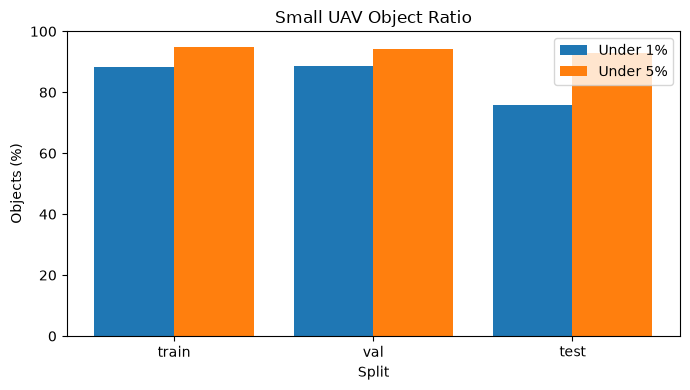

In [20]:
plt.figure(figsize=(7, 4))

x = range(len(stats_df))

plt.bar(
    [i - 0.2 for i in x],
    stats_df['1% 미만 객체(%)'],
    width=0.4,
    label='Under 1%'
)

plt.bar(
    [i + 0.2 for i in x],
    stats_df['5% 미만 객체(%)'],
    width=0.4,
    label='Under 5%'
)

plt.xticks(x, stats_df['split'])

plt.title('Small UAV Object Ratio')
plt.xlabel('Split')
plt.ylabel('Objects (%)')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

bbox 크기: 41 x 18 px
bbox 면적 비율: 0.0356 %


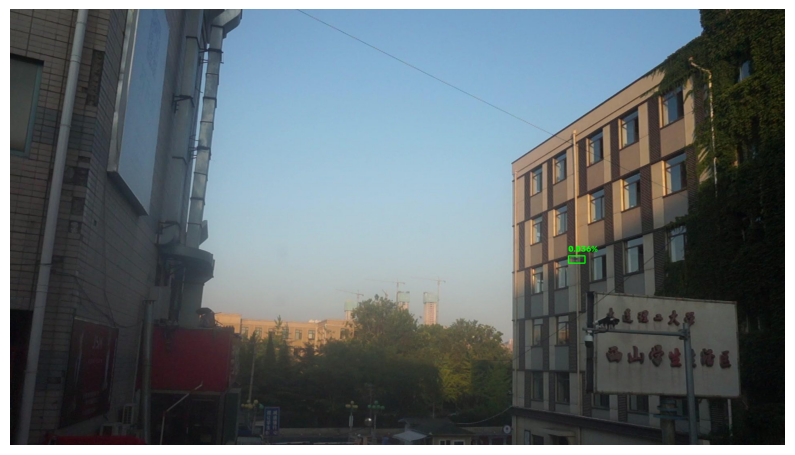

In [36]:
# 샘플 이미지 확인
# 직접 확인할 이미지와 XML 경로
number = "05192"
image_path = f"../data/raw/train/train/img/{number}.jpg"
xml_path = f"../data/raw/train/train/xml/{number}.xml"

# 이미지 읽기
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# XML에서 이미지 크기와 bbox 읽기
width, height, boxes = read_xml(xml_path)

# 이미지 전체 면적
image_area = width * height

for xmin, ymin, xmax, ymax in boxes:

    # bbox 크기
    bbox_width = xmax - xmin
    bbox_height = ymax - ymin
    bbox_area = bbox_width * bbox_height

    # 이미지 전체에서 bbox가 차지하는 비율
    bbox_ratio = bbox_area / image_area * 100

    # bbox 그리기
    cv2.rectangle(
        image,
        (xmin, ymin),
        (xmax, ymax),
        (0, 255, 0),
        2
    )

    # bbox 위에 비율 표시
    text = f"{bbox_ratio:.3f}%"

    cv2.putText(
        image,
        text,
        (xmin, max(ymin - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

    print("bbox 크기:", bbox_width, "x", bbox_height, "px")
    print("bbox 면적 비율:", round(bbox_ratio, 4), "%")

# 화면 출력
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

## 8. bbox 면적 분포 보기
train + val + test 객체를 합친 bbox 면적 비율 분포

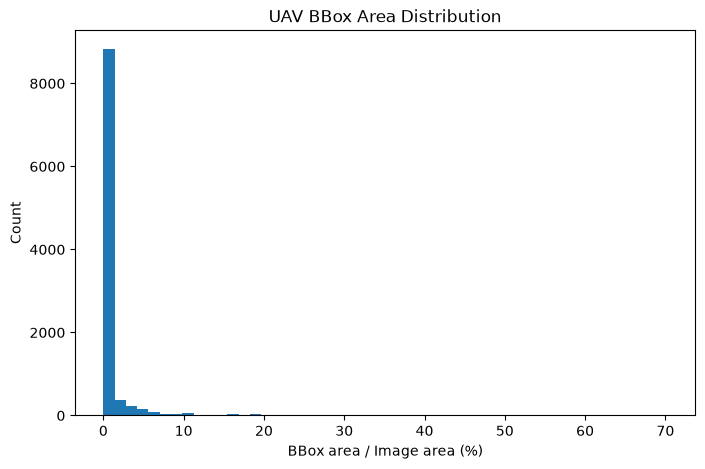

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df['bbox_ratio'] * 100, bins=50)
plt.xlabel('BBox area / Image area (%)')
plt.ylabel('Count')
plt.title('UAV BBox Area Distribution')
plt.show()


## 9. 640 입력 시 예상 bbox 크기

원본 이미지의 긴 변을 640으로 줄인다고 가정해 bbox가 어느 정도로 작아지는지 확인합니다.
실제 YOLO letterbox와 완전히 같은 계산은 아니고, 크기 감소 정도를 간단히 보기 위한 값입니다.

In [22]:
scale = 640 / df[['image_width', 'image_height']].max(axis=1)

df['bbox_width_640'] = df['bbox_width'] * scale
df['bbox_height_640'] = df['bbox_height'] * scale

print('640 기준 bbox width 중앙값:', round(df['bbox_width_640'].median(), 2), 'px')
print('640 기준 bbox height 중앙값:', round(df['bbox_height_640'].median(), 2), 'px')

small = (df['bbox_width_640'] < 10) | (df['bbox_height_640'] < 10)
print('한 변이 10px 미만인 객체:', round(small.mean() * 100, 2), '%')


640 기준 bbox width 중앙값: 15.0 px
640 기준 bbox height 중앙값: 8.0 px
한 변이 10px 미만인 객체: 60.95 %


## 10. 이미지 밝기와 대비 확인

- 밝기: grayscale 평균
- 대비: grayscale 표준편차

값 자체보다 train / val / test가 크게 다른지 보는 용도입니다.

In [23]:
rows = []

for split in ['train', 'val', 'test']:
    images = list((DATA_ROOT / split).rglob('*.jpg'))

    for image_path in images:
        gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        if gray is None:
            continue

        rows.append({
            'split': split,
            'brightness': gray.mean(),
            'contrast': gray.std()
        })

image_df = pd.DataFrame(rows)
image_df.groupby('split')[['brightness', 'contrast']].mean().round(2)


,brightness,contrast
split,,
test,122.44,57.16
train,116.06,60.94
val,116.08,60.82


# 11. 다중 객체 확인


In [25]:
from pathlib import Path
import xml.etree.ElementTree as ET

DATA_ROOT = Path("../data/raw")

for split in ["train", "val", "test"]:
    xml_files = sorted((DATA_ROOT / split).rglob("*.xml"))

    multi_object_files = []

    for xml_path in xml_files:
        root = ET.parse(xml_path).getroot()

        # UAV 객체 개수
        object_count = len(root.findall("object"))

        # 다중 객체 XML 목록
        if object_count > 1:
            multi_object_files.append((xml_path.name, object_count))

    print(f"\n[{split}]")
    print("전체 XML 수 :", len(xml_files))
    print("다중 객체 이미지 수 :", len(multi_object_files))
    print("다중 객체 비율 :", f"{len(multi_object_files) / len(xml_files) * 100:.2f}%")

    # 다중 객체 예시
    print("예시 :", multi_object_files[:10])


[train]
전체 XML 수 : 5200
다중 객체 이미지 수 : 29
다중 객체 비율 : 0.56%
예시 : [('00021.xml', 2), ('00065.xml', 6), ('00089.xml', 2), ('00140.xml', 2), ('00155.xml', 5), ('00156.xml', 2), ('00163.xml', 2), ('00235.xml', 2), ('00457.xml', 3), ('00458.xml', 3)]

[val]
전체 XML 수 : 2600
다중 객체 이미지 수 : 13
다중 객체 비율 : 0.50%
예시 : [('00005.xml', 6), ('00117.xml', 2), ('00119.xml', 2), ('00213.xml', 2), ('00229.xml', 3), ('00230.xml', 3), ('00231.xml', 3), ('00234.xml', 3), ('00304.xml', 2), ('00306.xml', 2)]

[test]
전체 XML 수 : 2200
다중 객체 이미지 수 : 33
다중 객체 비율 : 1.50%
예시 : [('00045.xml', 2), ('00120.xml', 3), ('00121.xml', 3), ('00122.xml', 3), ('00123.xml', 2), ('00124.xml', 2), ('00125.xml', 3), ('00126.xml', 3), ('00127.xml', 3), ('00128.xml', 2)]


Split : train
XML : ../data/raw/train/train/xml/00065.xml
객체 수 : 6
Image : ../data/raw/train/train/img/00065.jpg


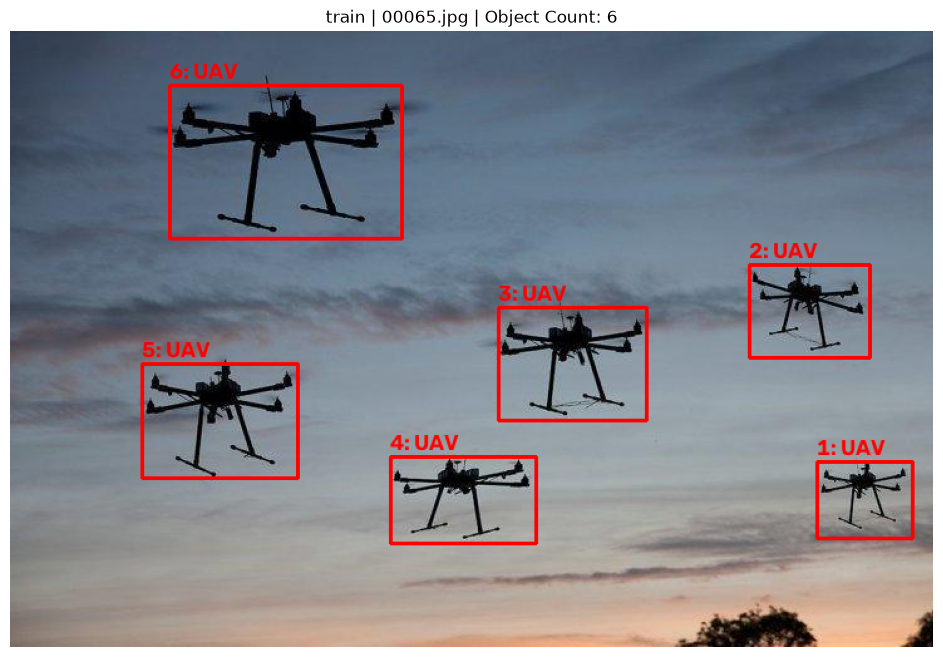

In [ ]:


DATA_ROOT = Path("../data/raw")

max_object_count = 0
max_xml_path = None
max_split = None


# 전체 XML 탐색
for split in ["train", "val", "test"]:

    xml_files = sorted((DATA_ROOT / split).rglob("*.xml"))

    for xml_path in xml_files:

        root = ET.parse(xml_path).getroot()

        # 이미지 내 객체 수
        object_count = len(root.findall("object"))

        # 최대 객체 수 갱신
        if object_count > max_object_count:
            max_object_count = object_count
            max_xml_path = xml_path
            max_split = split


print("Split :", max_split)
print("XML :", max_xml_path)
print("객체 수 :", max_object_count)


# XML 정보
root = ET.parse(max_xml_path).getroot()
filename = root.find("filename").text

# 동일 파일명 이미지 탐색
image_candidates = list((DATA_ROOT / max_split).rglob(filename))

if len(image_candidates) == 0:
    raise FileNotFoundError(f"이미지 없음: {filename}")

image_path = image_candidates[0]

print("Image :", image_path)


# 이미지 로드
image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# 전체 bbox 시각화
for i, obj in enumerate(root.findall("object"), start=1):

    class_name = obj.find("name").text
    box = obj.find("bndbox")

    xmin = int(float(box.find("xmin").text))
    ymin = int(float(box.find("ymin").text))
    xmax = int(float(box.find("xmax").text))
    ymax = int(float(box.find("ymax").text))

    # GT bbox
    cv2.rectangle(
        image,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        2
    )

    # 객체 번호 및 클래스
    cv2.putText(
        image,
        f"{i}: {class_name}",
        (xmin, max(ymin - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )


# 이미지 출력
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"{max_split} | {filename} | Object Count: {max_object_count}"
)
plt.show()

# 12.배경 확인

In [34]:
from pathlib import Path
import xml.etree.ElementTree as ET

DATA_ROOT = Path("../data/raw")

for split in ["train", "val", "test"]:

    split_path = DATA_ROOT / split

    # 이미지 및 XML 목록
    image_files = sorted(split_path.rglob("*.jpg"))
    xml_files = sorted(split_path.rglob("*.xml"))

    # 파일명 기준 XML 매핑
    xml_dict = {xml.stem: xml for xml in xml_files}

    background_count = 0
    no_xml_count = 0

    # 배경 이미지 파일명 저장
    background_files = []

    for image_path in image_files:

        # 동일 파일명 XML 탐색
        xml_path = xml_dict.get(image_path.stem)

        # XML 미존재 이미지
        if xml_path is None:
            no_xml_count += 1
            continue

        root = ET.parse(xml_path).getroot()

        # XML 내 객체 개수
        object_count = len(root.findall("object"))

        # 객체 0개 이미지
        if object_count == 0:
            background_count += 1
            background_files.append(image_path.name)

    # 비율 계산
    background_ratio = background_count / len(image_files) * 100
    no_xml_ratio = no_xml_count / len(image_files) * 100

    print(f"\n[{split}]")
    print("전체 이미지 수      :", len(image_files))
    print("배경 이미지 수      :", background_count)
    print("배경 이미지 비율    :", f"{background_ratio:.2f}%")
    print("XML 없는 이미지 수  :", no_xml_count)
    print("XML 없는 이미지 비율:", f"{no_xml_ratio:.2f}%")

    # 배경 이미지 파일명
    print("배경 이미지 파일명  :", background_files)


[train]
전체 이미지 수      : 5200
배경 이미지 수      : 3
배경 이미지 비율    : 0.06%
XML 없는 이미지 수  : 0
XML 없는 이미지 비율: 0.00%
배경 이미지 파일명  : ['00579.jpg', '00639.jpg', '00724.jpg']

[val]
전체 이미지 수      : 2600
배경 이미지 수      : 0
배경 이미지 비율    : 0.00%
XML 없는 이미지 수  : 0
XML 없는 이미지 비율: 0.00%
배경 이미지 파일명  : []

[test]
전체 이미지 수      : 2200
배경 이미지 수      : 0
배경 이미지 비율    : 0.00%
XML 없는 이미지 수  : 0
XML 없는 이미지 비율: 0.00%
배경 이미지 파일명  : []


# 이미지 유사도 확인

Train : 01507.jpg
Test  : 01591.jpg


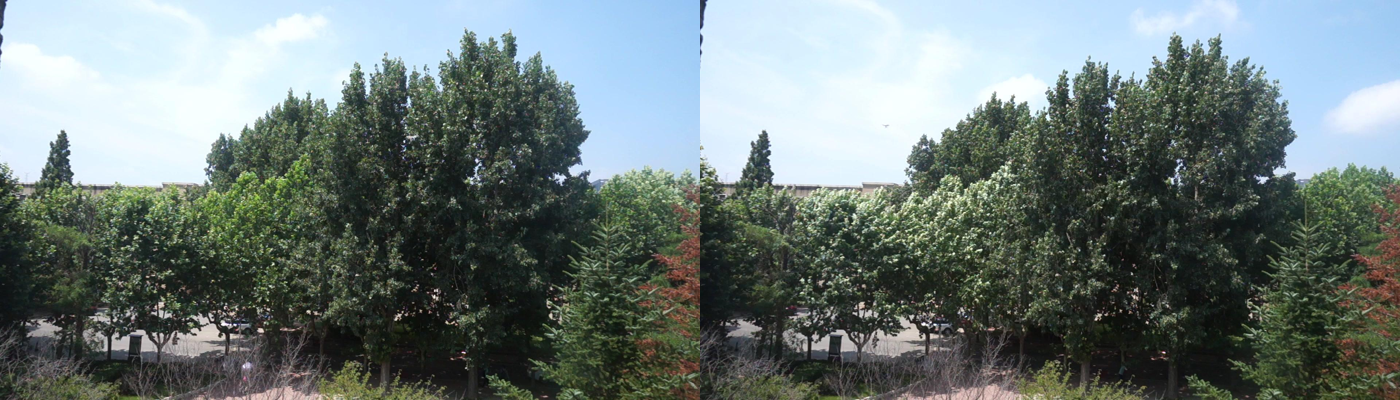

In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw
from IPython.display import display


# 프로젝트 루트
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

# 데이터 경로
DATA_DIR = ROOT / "data" / "yolo_subset"

# 비교할 이미지명
TRAIN_IMAGE = "01507.jpg"
TEST_IMAGE = "01591.jpg"


def load_boxes(label_path):
    boxes = []

    for line in label_path.read_text().splitlines():
        parts = line.split()

        if len(parts) >= 5:
            _, x, y, w, h = map(float, parts)

            boxes.append([
                x - w / 2,
                y - h / 2,
                x + w / 2,
                y + h / 2,
            ])

    return boxes


def draw_gt(image, label_path):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    width, height = image.size

    for box in load_boxes(label_path):
        x1, y1, x2, y2 = box

        draw.rectangle(
            (
                x1 * width,
                y1 * height,
                x2 * width,
                y2 * height,
            ),
            outline="lime",
            width=2,
        )

        draw.text(
            (x1 * width, max(0, y1 * height - 12)),
            "GT",
            fill="lime",
        )

    return image


def compare_train_test(train_name, test_name):
    train_path = DATA_DIR / "images" / "train" / train_name
    test_path = DATA_DIR / "images" / "test" / test_name

    train_label = DATA_DIR / "labels" / "train" / f"{Path(train_name).stem}.txt"
    test_label = DATA_DIR / "labels" / "test" / f"{Path(test_name).stem}.txt"

    train_image = Image.open(train_path).convert("RGB")
    test_image = Image.open(test_path).convert("RGB")

    train_image = draw_gt(train_image, train_label)
    test_image = draw_gt(test_image, test_label)

    size = (700, 400)

    train_image = train_image.resize(size)
    test_image = test_image.resize(size)

    canvas = Image.new(
        "RGB",
        (size[0] * 2, size[1]),
        "white",
    )

    canvas.paste(train_image, (0, 0))
    canvas.paste(test_image, (size[0], 0))

    print(f"Train : {train_name}")
    print(f"Test  : {test_name}")
    print("초록색 = GT")

    display(canvas)


compare_train_test(
    TRAIN_IMAGE,
    TEST_IMAGE,
)